This project focusses on developing a sentiment analysis system using social media posts.

It uses natural language processing techniques, the system aims to automatically identify and categorze the sentiment expressed within social media content.

The dataset used can be found on Kaggle :
https://www.kaggle.com/datasets/mdismielhossenabir/sentiment-analysis



In [ ]:
!pip install transformers vaderSentiment textblob

# Importing necessary tools

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Pandas :", pd.__version__)
print("Numpy :", np.__version__)
print("Seaborn :", sns.__version__)

Pandas : 2.2.2
Numpy : 2.0.2
Seaborn : 0.13.2


# Importing the dataset

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Mood Tracker/sentiment_analysis.csv")
df.head(7)

,Year,Month,Day,Time of Tweet,text,sentiment,Platform
0,2018,8,18,morning,What a great day!!! Looks like dream.,positive,Twitter
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook
2,2017,8,18,night,Don't angry me,negative,Facebook
3,2022,6,8,morning,We attend in the class just for listening teac...,negative,Facebook
4,2022,6,8,noon,"Those who want to go, let them go",negative,Instagram
5,2016,11,22,night,"Its night 2 am, feeling neutral",neutral,Facebook
6,2017,12,28,morning,2 am feedings for the baby are fun when he is ...,positive,Facebook


# Tackling date

### Merging 'Year', 'Month', 'Day' into 'Date'

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           499 non-null    int64 
 1   Month          499 non-null    int64 
 2   Day            499 non-null    int64 
 3   Time of Tweet  499 non-null    object
 4   text           499 non-null    object
 5   sentiment      499 non-null    object
 6   Platform       499 non-null    object
dtypes: int64(3), object(4)
memory usage: 27.4+ KB


In [4]:
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
df.head(7)

,Year,Month,Day,Time of Tweet,text,sentiment,Platform,Date
0,2018,8,18,morning,What a great day!!! Looks like dream.,positive,Twitter,2018-08-18
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook,2018-08-18
2,2017,8,18,night,Don't angry me,negative,Facebook,2017-08-18
3,2022,6,8,morning,We attend in the class just for listening teac...,negative,Facebook,2022-06-08
4,2022,6,8,noon,"Those who want to go, let them go",negative,Instagram,2022-06-08
5,2016,11,22,night,"Its night 2 am, feeling neutral",neutral,Facebook,2016-11-22
6,2017,12,28,morning,2 am feedings for the baby are fun when he is ...,positive,Facebook,2017-12-28


### Dropping 'Year', 'Month', 'Day' columns

In [7]:
#df.drop(['Year', 'Month', 'Day'], axis=1, inplace=True)
df.head(7)

,Time of Tweet,text,sentiment,Platform,Date
0,morning,What a great day!!! Looks like dream.,positive,Twitter,2018-08-18
1,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook,2018-08-18
2,night,Don't angry me,negative,Facebook,2017-08-18
3,morning,We attend in the class just for listening teac...,negative,Facebook,2022-06-08
4,noon,"Those who want to go, let them go",negative,Instagram,2022-06-08
5,night,"Its night 2 am, feeling neutral",neutral,Facebook,2016-11-22
6,morning,2 am feedings for the baby are fun when he is ...,positive,Facebook,2017-12-28


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Time of Tweet  499 non-null    object        
 1   text           499 non-null    object        
 2   sentiment      499 non-null    object        
 3   Platform       499 non-null    object        
 4   Date           499 non-null    datetime64[ns]
dtypes: datetime64[ns](1), object(4)
memory usage: 19.6+ KB


# Tackling NuLL values

### Checking for missing entries in 'text' column

In [9]:
df['text'].isnull().sum()

np.int64(0)

In [10]:
df['sentiment'].isnull().sum()

np.int64(0)

### Categorizing sentiments

In [11]:
sentiment_map = {'positive':1, 'neutral':0, 'negative':-1}
df['sentiment_score'] = df['sentiment'].map(sentiment_map)
df.head()

,Time of Tweet,text,sentiment,Platform,Date,sentiment_score
0,morning,What a great day!!! Looks like dream.,positive,Twitter,2018-08-18,1
1,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook,2018-08-18,1
2,night,Don't angry me,negative,Facebook,2017-08-18,-1
3,morning,We attend in the class just for listening teac...,negative,Facebook,2022-06-08,-1
4,noon,"Those who want to go, let them go",negative,Instagram,2022-06-08,-1


# Finding Mood Trends

<Axes: xlabel='Date'>

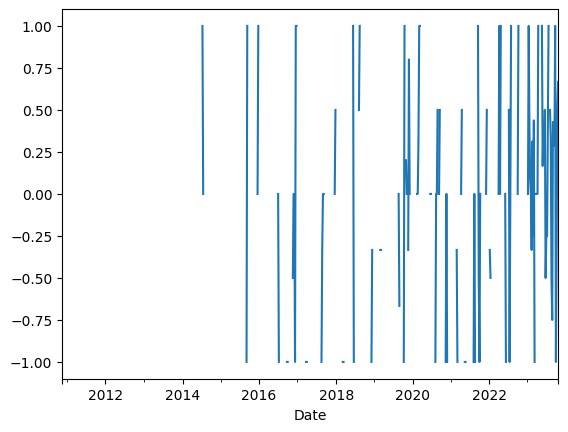

In [12]:
# Setting the Date as the index
df = df.set_index('Date')

df['day_name'] = df.index.day_name()

df['sentiment_score'].resample('W').mean().plot()

# Visualization

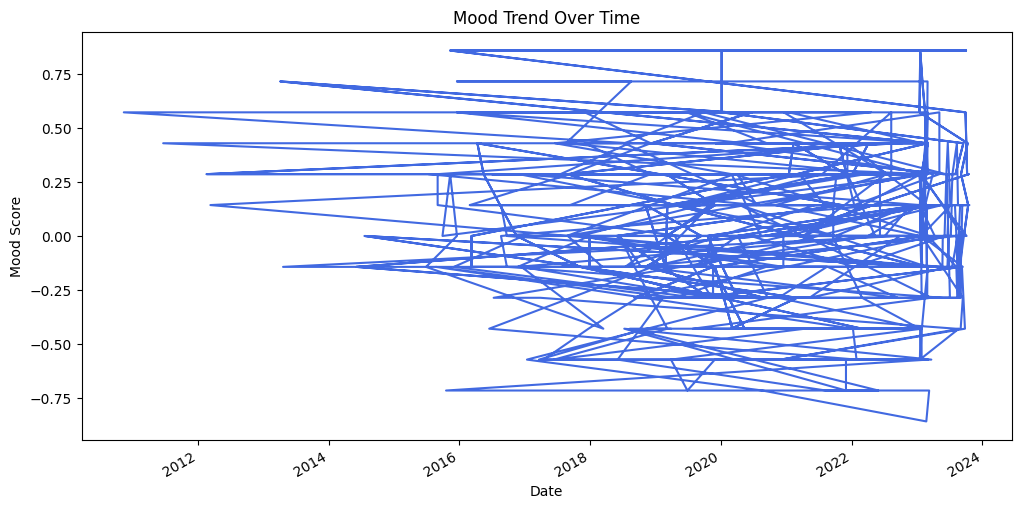

In [13]:
plt.figure(figsize=(12,6))
df['sentiment_score'].rolling(window=7).mean().plot(label='7-Day Average', color='royalblue')
plt.title('Mood Trend Over Time')
plt.ylabel('Mood Score')
plt.show()

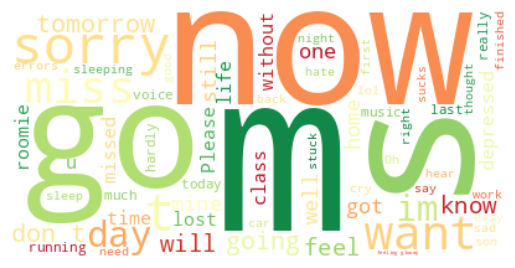

In [14]:
# Finding frequencies of words used for -ve entries
from wordcloud import WordCloud
neg_text = " ".join(df[df['sentiment_score'] < 0]['text'])
wordcloud = WordCloud(background_color="white", colormap="RdYlGn").generate(neg_text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.savefig("frequencies_of_words.png")
plt.show()

The model we'll use is ***bhadresh-savani/distilbert-base-uncased-emotion***. It’s perfect because it's "Distilled" (smaller and faster) but can accurately detect six specific emotions:

1. Joy
2. Sadness
3. Anger
4. Fear
5. Love
6. Surprise

# Model 1

## Installing and Loading the model

In [15]:
!pip install -q transformers torch
from transformers import pipeline

classifier = pipeline('text-classification',
                      model = 'bhadresh-savani/distilbert-base-uncased-emotion',
                      return_all_scores = False,
                      device=0)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

## Ran emotion detection on dataset

In [16]:
df_sample = df.head(500).copy()

def get_emotion(text):
    try:
        prediction = classifier(text[:512])
        return prediction[0]['label']
    except:
        return "unknown"

print("Analyzing emotions... this may take a minute.")
df_sample['detected_emotion'] = df_sample['text'].apply(get_emotion)

df_sample[['text', 'detected_emotion']].head()

Analyzing emotions... this may take a minute.


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,text,detected_emotion
Date,,
2018-08-18,What a great day!!! Looks like dream.,joy
2018-08-18,"I feel sorry, I miss you here in the sea beach",sadness
2017-08-18,Don't angry me,anger
2022-06-08,We attend in the class just for listening teac...,joy
2022-06-08,"Those who want to go, let them go",anger


## Visualizing emotional profile

/tmp/ipykernel_1785/3318896617.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sample, x='detected_emotion', palette='viridis', order=df_sample['detected_emotion'].value_counts().index)


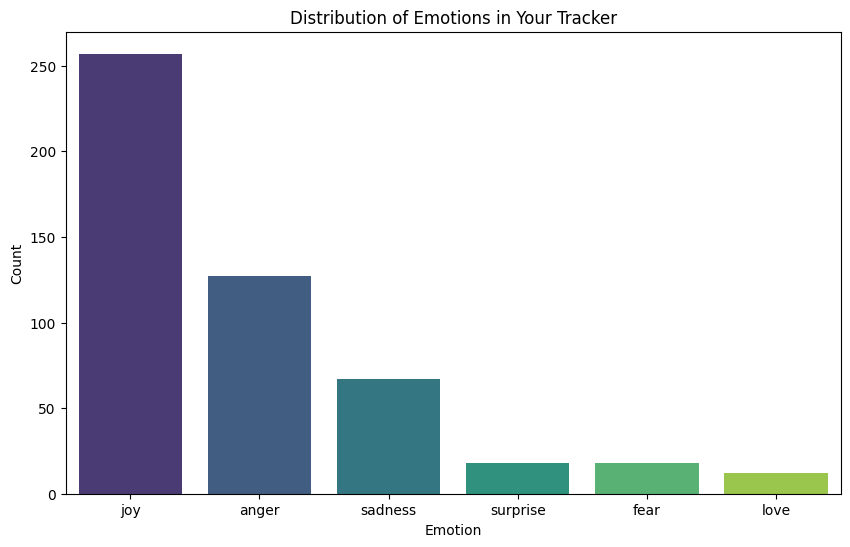

In [17]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_sample, x='detected_emotion', palette='viridis', order=df_sample['detected_emotion'].value_counts().index)
plt.title('Distribution of Emotions in Your Tracker')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.savefig('types_of_emotions.png')
plt.show()

## Classification Report

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

# mapping logic used
mapping = {'joy': 'positive', 'love': 'positive', 'sadness': 'negative',
           'anger': 'negative', 'fear': 'negative', 'surprise': 'neutral'}

df_sample['mapped_sentiment'] = df_sample['detected_emotion'].map(mapping)

# Comparing with the original 'sentiment' column
print(classification_report(df_sample['sentiment'], df_sample['mapped_sentiment']))

              precision    recall  f1-score   support

    negative       0.50      0.78      0.61       134
     neutral       0.06      0.01      0.01       199
    positive       0.49      0.80      0.61       166

    accuracy                           0.48       499
   macro avg       0.35      0.53      0.41       499
weighted avg       0.32      0.48      0.37       499



# Model 2

Using another 3-way model instead of 6-way model

## Installing and loading the model

In [21]:
# This model is specifically for 3-class Sentiment
classifier = pipeline("sentiment-analysis",
                      model="cardiffnlp/twitter-roberta-base-sentiment-latest",
                      device=0)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Ran emotion detection

In [22]:
df_sample = df.head(500).copy()

def get_emotion(text):
    try:
        prediction = classifier(text[:512])
        return prediction[0]['label']
    except:
        return "unknown"

print("Analyzing emotions... this may take a minute.")
df_sample['detected_emotion'] = df_sample['text'].apply(get_emotion)

df_sample[['text', 'detected_emotion']].head()

Analyzing emotions... this may take a minute.


,text,detected_emotion
Date,,
2018-08-18,What a great day!!! Looks like dream.,positive
2018-08-18,"I feel sorry, I miss you here in the sea beach",negative
2017-08-18,Don't angry me,negative
2022-06-08,We attend in the class just for listening teac...,negative
2022-06-08,"Those who want to go, let them go",neutral


## Visualizing emotional profile

/tmp/ipykernel_1785/1385099138.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sample, x='detected_emotion', palette='viridis', order=df_sample['detected_emotion'].value_counts().index)


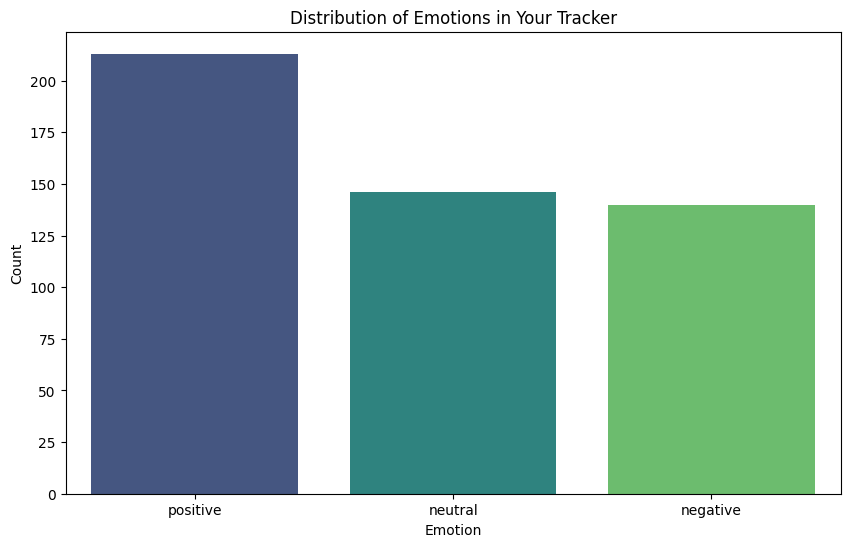

In [23]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_sample, x='detected_emotion', palette='viridis', order=df_sample['detected_emotion'].value_counts().index)
plt.title('Distribution of Emotions in Your Tracker')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.savefig('emotion_profile.png')
plt.show()

In [24]:
from sklearn.metrics import classification_report
print("--- New Model Performance ---")
print(classification_report(df_sample['sentiment'], df_sample['detected_emotion']))

--- New Model Performance ---
              precision    recall  f1-score   support

    negative       0.74      0.77      0.75       134
     neutral       0.77      0.56      0.65       199
    positive       0.68      0.87      0.76       166

    accuracy                           0.72       499
   macro avg       0.73      0.73      0.72       499
weighted avg       0.73      0.72      0.71       499



In [25]:
# Define the inference function for the NEW model
def get_new_sentiment(text):
    try:
        # Truncate to 512 characters for BERT-based models
        result = classifier(text[:512])
        return result[0]['label']
    except:
        return "unknown"

# RUN INFERENCE (This creates the missing column)
print("Running inference with the new model...")
df_sample['detected_emotion'] = df_sample['text'].apply(get_new_sentiment)

from sklearn.metrics import classification_report
print("\n--- New Model Performance ---")
print(classification_report(df_sample['sentiment'], df_sample['detected_emotion']))

Running inference with the new model...

--- New Model Performance ---
              precision    recall  f1-score   support

    negative       0.74      0.77      0.75       134
     neutral       0.77      0.56      0.65       199
    positive       0.68      0.87      0.76       166

    accuracy                           0.72       499
   macro avg       0.73      0.73      0.72       499
weighted avg       0.73      0.72      0.71       499



# Comparing the classification report of two models

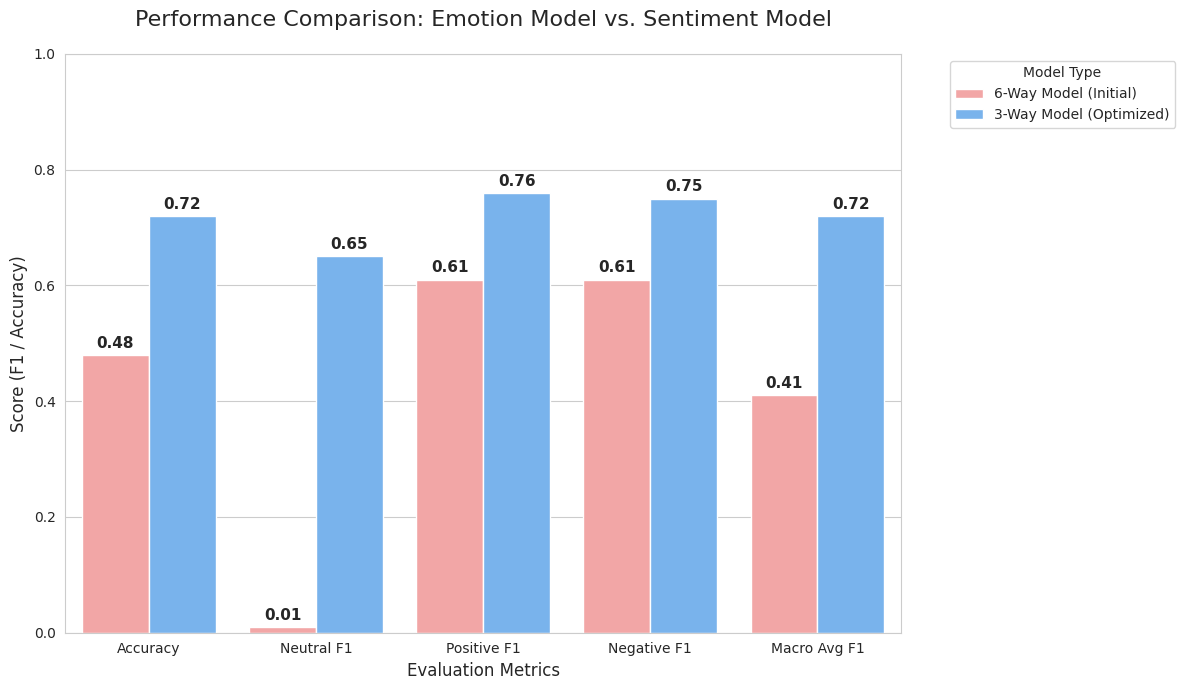

In [26]:
data = {
    'Metric': ['Accuracy', 'Neutral F1', 'Positive F1', 'Negative F1', 'Macro Avg F1'],
    '6-Way Model (Initial)': [0.48, 0.01, 0.61, 0.61, 0.41],
    '3-Way Model (Optimized)': [0.72, 0.65, 0.76, 0.75, 0.72]
}

df_plot = pd.DataFrame(data)

# 2. Reshape data for Seaborn (Melt it)
df_melted = df_plot.melt(id_vars='Metric', var_name='Model', value_name='Score')

# 3. Create the Plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Create grouped bar chart
ax = sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette=['#ff9999','#66b3ff'])

# 4. Add "Value Labels" on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontweight='bold', fontsize=11)

# 5. Final Polish
plt.title('Performance Comparison: Emotion Model vs. Sentiment Model', fontsize=16, pad=20)
plt.ylim(0, 1.0) # Scores are between 0 and 1
plt.ylabel('Score (F1 / Accuracy)', fontsize=12)
plt.xlabel('Evaluation Metrics', fontsize=12)
plt.legend(title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('model_comparison.png') # Saves the image
plt.show()

In [28]:
import os
save_path = "./mood_model_production"
os.makedirs(save_path, exist_ok=True)

# Saving the  model and the tokenizer
classifier.model.save_pretrained(save_path)
classifier.tokenizer.save_pretrained(save_path)

print(f"Model and Tokenizer saved successfully to {save_path}!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and Tokenizer saved successfully to ./mood_model_production!
